# 03 · Exploratory Data Analysis
**Goal:** Discover impulse-vs-planned behaviour patterns from the cleaned data.

In [1]:
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/processed/cleaned.csv')
print('Loaded cleaned data:', df.shape)

Loaded cleaned data: (13000, 36)


## Univariate Analysis

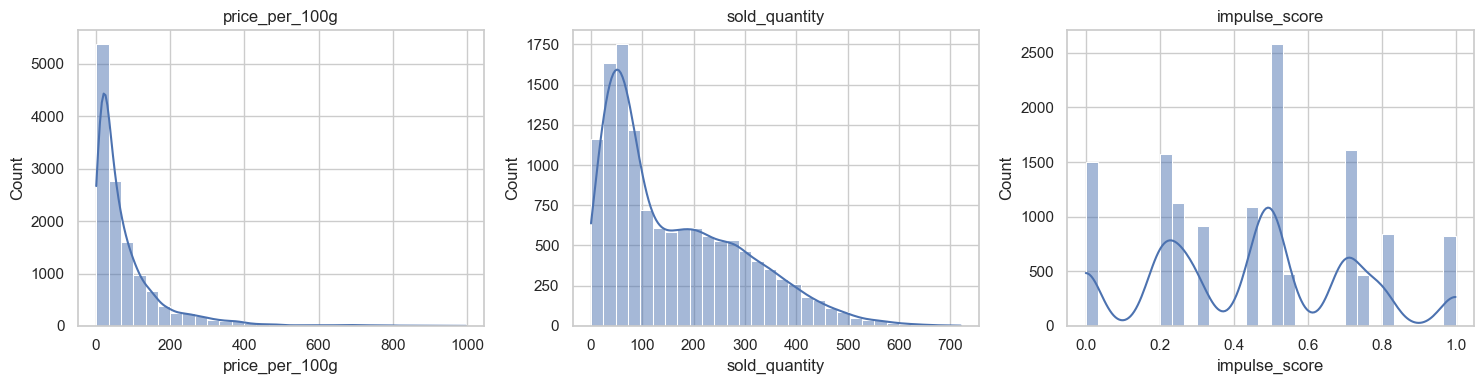

Univariate plots saved.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['price_per_100g','sold_quantity','impulse_score']):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('uni_plots.png', dpi=100)
plt.show()
plt.close()
print('Univariate plots saved.')

In [3]:
print('-- Category counts --')
print(df['category'].value_counts())
print('\n-- Basket type counts --')
print(df['basket_type'].value_counts())

-- Category counts --
category
bakery                 1713
grocery                1700
dairy                  1662
personal care          1620
snacks                 1596
fruits & vegetables    1588
beverages              1561
household              1560
Name: count, dtype: int64

-- Basket type counts --
basket_type
Planned    5117
Mixed      4139
Impulse    3744
Name: count, dtype: int64


## Bivariate Analysis

/var/folders/x7/kph4sypj62b9k8w59g173t1h0000gn/T/ipykernel_86076/1148994903.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  pct = (cat_rev.div(cat_rev.sum(1), axis=0)*100).round(1)


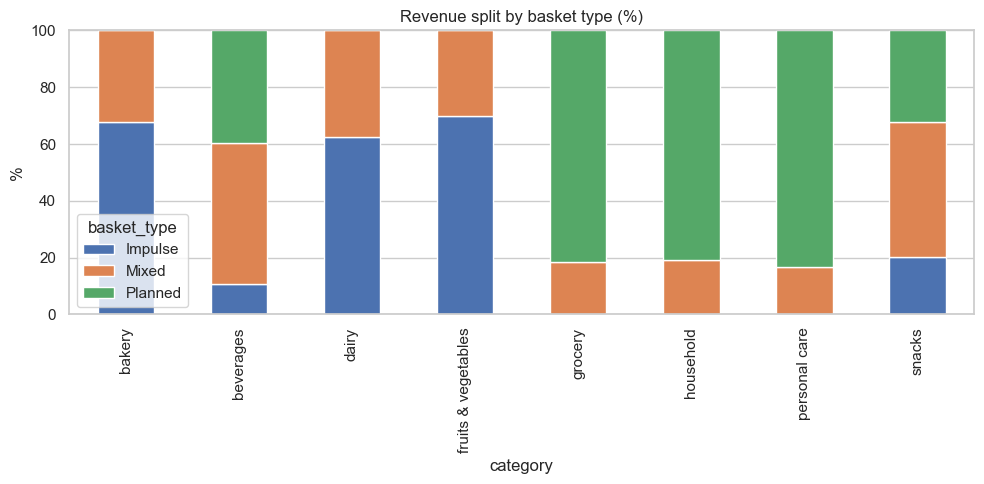

Category x Basket revenue %:
basket_type          Impulse  Mixed  Planned
category                                    
bakery                  67.6   32.4      0.0
beverages               10.8   49.7     39.5
dairy                   62.3   37.7      0.0
fruits & vegetables     69.8   30.2      0.0
grocery                  0.0   18.5     81.5
household                0.0   19.1     80.9
personal care            0.0   16.8     83.2
snacks                  20.2   47.4     32.4


In [4]:
# 1. Category vs impulse revenue share
cat_rev = df.groupby(['category','basket_type'])['revenue_inr'].sum().unstack(fill_value=0)
pct = (cat_rev.div(cat_rev.sum(1), axis=0)*100).round(1)
pct.plot(kind='bar', stacked=True, figsize=(10,5), title='Revenue split by basket type (%)')
plt.ylabel('%')
plt.tight_layout()
plt.savefig('cat_basket_rev.png', dpi=100)
plt.show()
plt.close()
print('Category x Basket revenue %:')
print(pct)

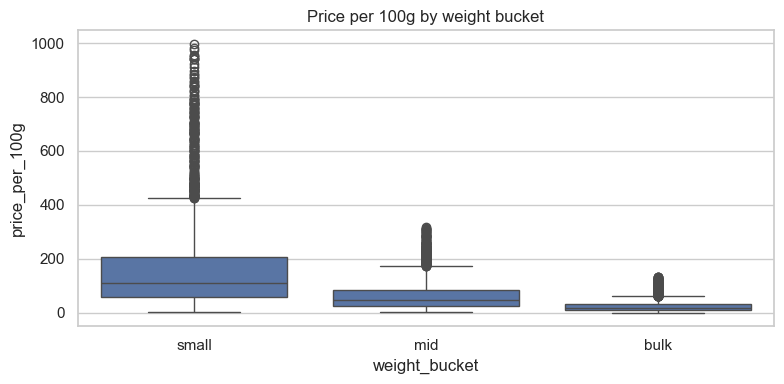

Median price/100g by weight bucket:
weight_bucket
bulk      18.32
mid       47.93
small    110.44
Name: price_per_100g, dtype: float64


In [5]:
# 2. Weight bucket vs price per 100g
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=df, x='weight_bucket', y='price_per_100g', order=['small','mid','bulk'], ax=ax)
ax.set_title('Price per 100g by weight bucket')
plt.tight_layout()
plt.savefig('weight_price.png', dpi=100)
plt.show()
plt.close()
print('Median price/100g by weight bucket:')
print(df.groupby('weight_bucket')['price_per_100g'].median().round(2))

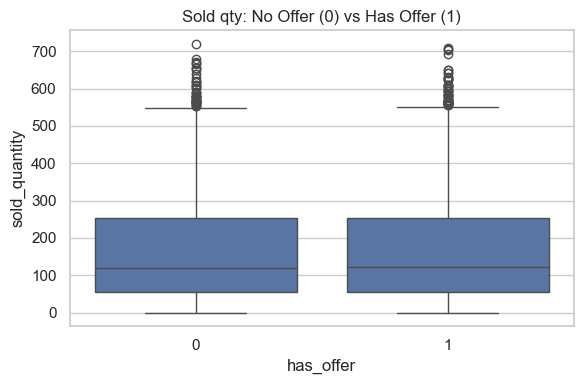

Mean sold_quantity by offer:
has_offer
0    161.5
1    163.4
Name: sold_quantity, dtype: float64


In [6]:
# 3. Offer vs sold quantity
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='has_offer', y='sold_quantity', ax=ax)
ax.set_title('Sold qty: No Offer (0) vs Has Offer (1)')
plt.tight_layout()
plt.savefig('offer_qty.png', dpi=100)
plt.show()
plt.close()
print('Mean sold_quantity by offer:')
print(df.groupby('has_offer')['sold_quantity'].mean().round(1))

/var/folders/x7/kph4sypj62b9k8w59g173t1h0000gn/T/ipykernel_86076/2800910014.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  imp_share = (city_rev['Impulse'] / city_rev.sum(1) * 100).sort_values()


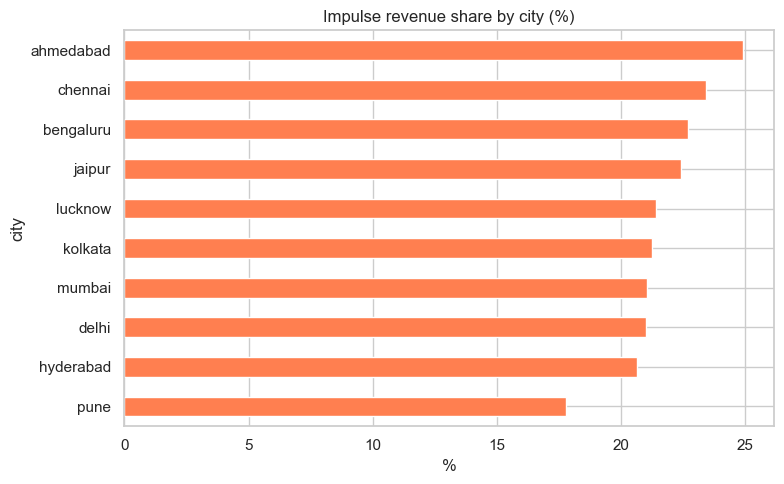

Impulse revenue % by city:
city
pune         17.8
hyderabad    20.6
delhi        21.0
mumbai       21.1
kolkata      21.3
lucknow      21.4
jaipur       22.4
bengaluru    22.7
chennai      23.4
ahmedabad    24.9
dtype: float64


In [7]:
# 4. City vs impulse share
city_rev = df.groupby(['city','basket_type'])['revenue_inr'].sum().unstack(fill_value=0)
if 'Impulse' in city_rev.columns:
    imp_share = (city_rev['Impulse'] / city_rev.sum(1) * 100).sort_values()
    imp_share.plot(kind='barh', color='coral', title='Impulse revenue share by city (%)', figsize=(8,5))
    plt.xlabel('%')
    plt.tight_layout()
    plt.savefig('city_impulse.png', dpi=100)
    plt.show()
    plt.close()
    print('Impulse revenue % by city:')
    print(imp_share.round(1))
else:
    print('No Impulse basket rows found.')

## Multivariate Analysis

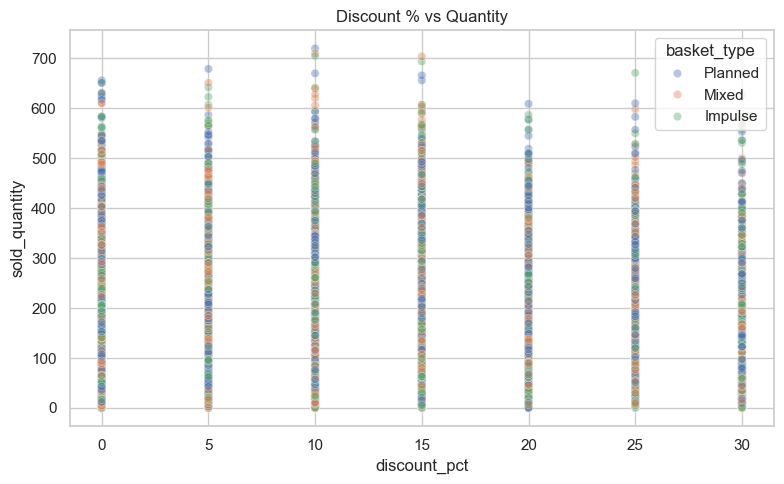

Scatter plot saved.


In [8]:
# Discount vs quantity by basket type
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x='discount_pct', y='sold_quantity', hue='basket_type', alpha=.4, ax=ax)
ax.set_title('Discount % vs Quantity')
plt.tight_layout()
plt.savefig('disc_qty.png', dpi=100)
plt.show()
plt.close()
print('Scatter plot saved.')

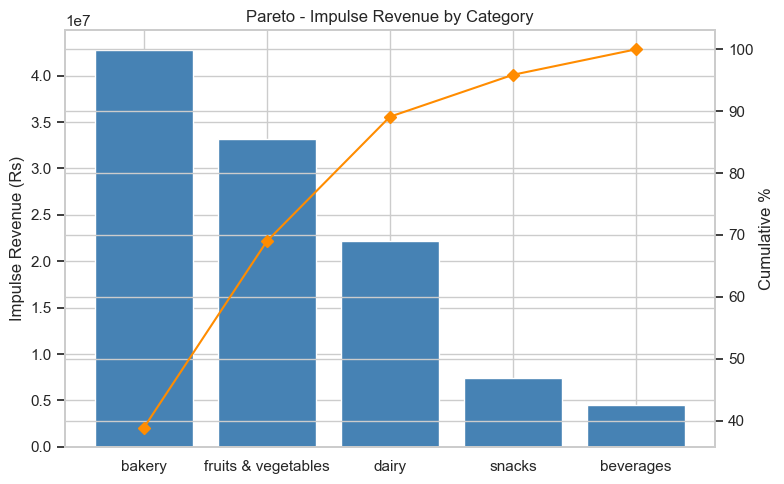

Pareto data:
           category  revenue_inr    cum_pct
             bakery  42746638.33  38.813552
fruits & vegetables  33218529.31  68.975669
              dairy  22169157.19  89.105059
             snacks   7463553.60  95.881896
          beverages   4535402.87 100.000000


In [9]:
# Pareto: top categories driving impulse revenue
imp = df[df['basket_type']=='Impulse']
if len(imp) > 0:
    par = imp.groupby('category')['revenue_inr'].sum().sort_values(ascending=False).reset_index()
    par['cum_pct'] = par['revenue_inr'].cumsum() / par['revenue_inr'].sum() * 100
    fig, ax1 = plt.subplots(figsize=(8,5))
    ax1.bar(par['category'], par['revenue_inr'], color='steelblue')
    ax1.set_ylabel('Impulse Revenue (Rs)')
    ax2 = ax1.twinx()
    ax2.plot(par['category'], par['cum_pct'], 'D-', color='darkorange')
    ax2.set_ylabel('Cumulative %')
    plt.title('Pareto - Impulse Revenue by Category')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('pareto.png', dpi=100)
    plt.show()
    plt.close()
    print('Pareto data:')
    print(par[['category','revenue_inr','cum_pct']].to_string(index=False))
else:
    print('No Impulse rows found.')

## Summary Metrics

In [10]:
total_rev = df['revenue_inr'].sum()
imp_rev = df[df['basket_type']=='Impulse']['revenue_inr'].sum()
plan_rev = df[df['basket_type']=='Planned']['revenue_inr'].sum()
mix_rev = df[df['basket_type']=='Mixed']['revenue_inr'].sum()
print(f'Total revenue        : Rs {total_rev:,.0f}')
print(f'Impulse revenue      : Rs {imp_rev:,.0f}  ({imp_rev/total_rev*100:.1f}%)')
print(f'Planned revenue      : Rs {plan_rev:,.0f}  ({plan_rev/total_rev*100:.1f}%)')
print(f'Mixed revenue        : Rs {mix_rev:,.0f}  ({mix_rev/total_rev*100:.1f}%)')
print()
print('Avg price/100g by weight bucket:')
print(df.groupby('weight_bucket')['price_per_100g'].mean().round(2))
print()
print('Avg qty sold - offer vs no offer:')
print(df.groupby('has_offer')['sold_quantity'].mean().round(1))

Total revenue        : Rs 509,027,130
Impulse revenue      : Rs 110,133,281  (21.6%)
Planned revenue      : Rs 260,732,193  (51.2%)
Mixed revenue        : Rs 138,161,656  (27.1%)

Avg price/100g by weight bucket:
weight_bucket
bulk      24.46
mid       62.83
small    155.86
Name: price_per_100g, dtype: float64

Avg qty sold - offer vs no offer:
has_offer
0    161.5
1    163.4
Name: sold_quantity, dtype: float64
